### Data Loading & Processing

In [27]:
import pandas as pd
from scipy.stats import pearsonr

df = pd.read_csv('../final_pl_elections_weather_2004_2025.csv')
df['date'] = pd.to_datetime(df['date'])
df['elections_date'] = df['date'].dt.strftime('%Y-%m-%d')
df['total_precipitation'] = df['total_precipitation'].clip(lower=0)

### Feature Correlation Check (Multicollinearity)

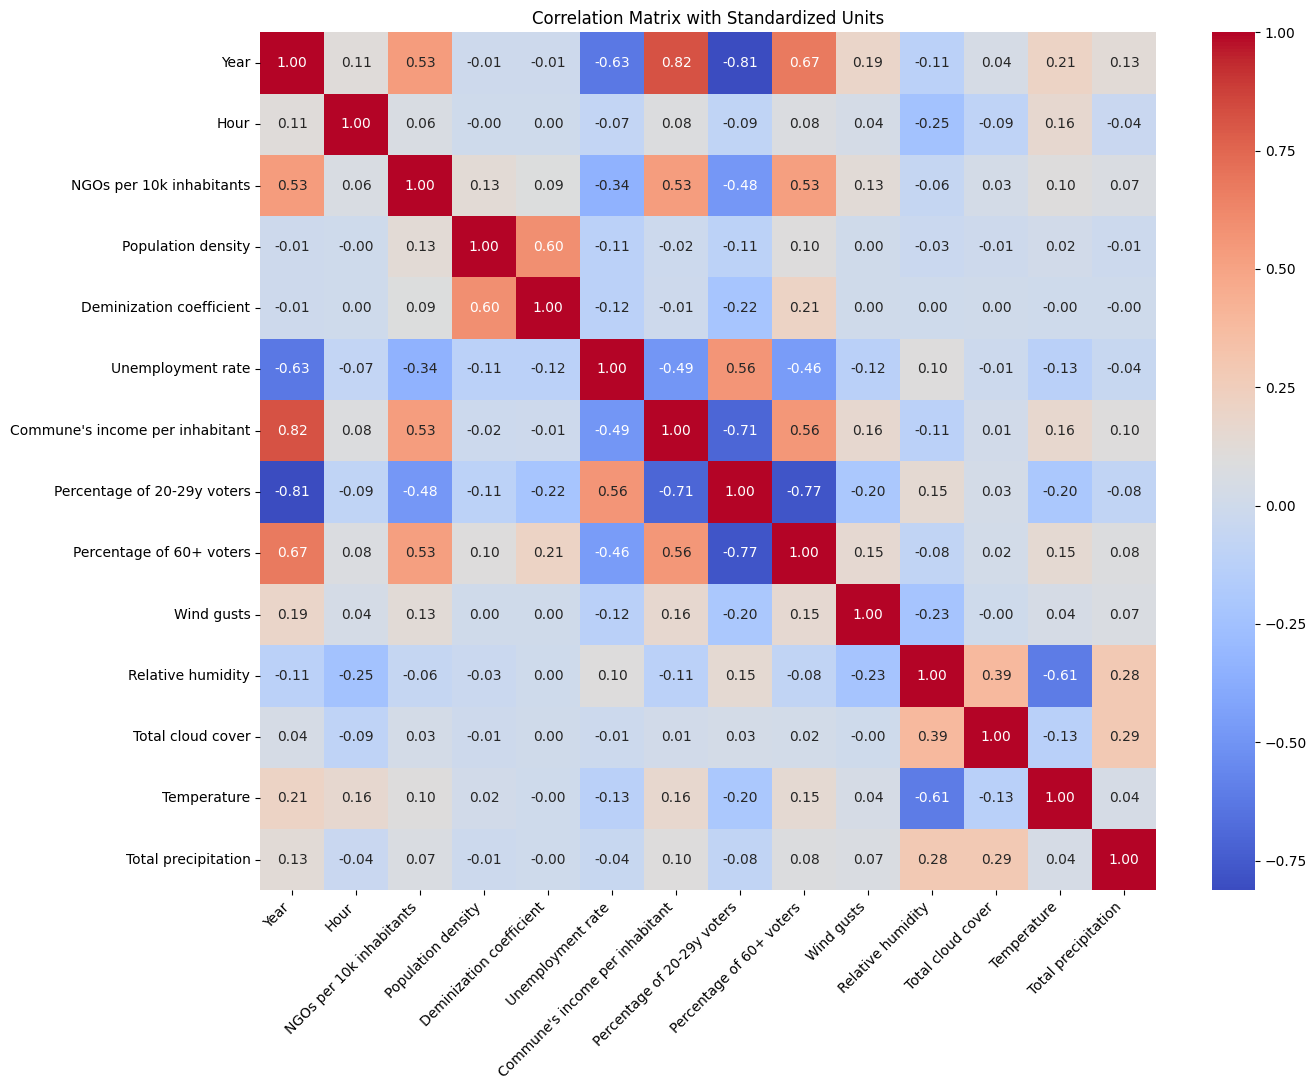

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df_weather = df[['year','hour','ngos_per_10k_inhabitants','population_density','feminization_coefficient','unemployment_rate','income_per_inhabitant',
                 'perc_of_20-29','perc_of_60+','wind_gusts','rel_humidity','total_cloud_cover','temperature','total_precipitation']]


correlation_matrix = df_weather.corr(numeric_only=True)


label_mapping = {
    'year' : 'Year',
    'hour' : 'Hour',
    'ngos_per_10k_inhabitants': "NGOs per 10k inhabitants",
    'population_density': r"Population density",
    'feminization_coefficient': 'Deminization coefficient',
    'unemployment_rate': 'Unemployment rate',
    'income_per_inhabitant': "Commune's income per inhabitant",
    'perc_of_20-29' : 'Percentage of 20-29y voters',
    'perc_of_60+' : 'Percentage of 60+ voters',
    'wind_gusts' : 'Wind gusts',
    'rel_humidity' : 'Relative humidity',
    'total_cloud_cover' : 'Total cloud cover',
    'temperature' : 'Temperature',
    'total_precipitation' : 'Total precipitation'
}

new_labels = [label_mapping.get(col, col) for col in correlation_matrix.columns]

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    xticklabels=new_labels, 
    yticklabels=new_labels
)

plt.title("Correlation Matrix with Standardized Units")
plt.xticks(rotation=45, ha='right') # Obracamy dolne napisy dla lepszej czytelności
plt.tight_layout()
plt.show()

### Calculate the regression model

Note: C(TERYT) itself introduces ~2500 dummy variables. 

In [29]:
import statsmodels.formula.api as smf

formula = """
turnout_delta ~ I(total_precipitation  ** 0.5) +
                total_precipitation +
                temperature + 
                I(temperature ** 2) +
                wind_gusts +
                rel_humidity +
                total_cloud_cover +
                C(TERYT) +
                C(hour) +
                C(elections_date) +
                Q('perc_of_60+') +
                Q('population_density') +
                Q('feminization_coefficient') +
                Q('unemployment_rate') +
                Q('ngos_per_10k_inhabitants') +
                Q('income_per_inhabitant')
                
                     
"""       

fe_model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['TERYT']})
summary = fe_model.summary()

print(summary.tables[0])

results_df = pd.read_html(summary.tables[1].as_html(), header=0, index_col=0)[0]
main_results = results_df[~results_df.index.str.contains('TERYT')]

print("\n--- KEY COEFFICIENTS ---")
print(main_results.to_markdown())

KeyboardInterrupt: 

### Calculate the variance inflation factor

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = df_weather.dropna()
X_vif = X_vif.astype(float)
X_vif['intercept'] = 1 

vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data[vif_data['variable'] != 'intercept'].sort_values(by='VIF', ascending=False).to_markdown())

|    | variable                 |     VIF |
|---:|:-------------------------|--------:|
|  0 | year                     | 5.84839 |
|  7 | perc_of_20-29            | 4.70439 |
|  6 | income_per_inhabitant    | 3.244   |
|  8 | perc_of_60+              | 2.75794 |
| 10 | rel_humidity             | 2.40789 |
| 12 | temperature              | 1.86642 |
|  4 | feminization_coefficient | 1.81419 |
|  5 | unemployment_rate        | 1.72221 |
|  2 | ngos_per_10k_inhabitants | 1.61221 |
|  3 | population_density       | 1.59938 |
| 13 | total_precipitation      | 1.265   |
| 11 | total_cloud_cover        | 1.2591  |
|  9 | wind_gusts               | 1.16285 |
|  1 | hour                     | 1.07658 |
